
FULLY PRACTICAL SHAPE & OBJECT REPRESENTATION
ALL computations performed on YOUR image

✅ Detects contours from YOUR image
✅ Computes properties of YOUR contours
✅ Classifies shapes in YOUR image
✅ Compares shapes in YOUR image
✅ Extracts skeleton from YOUR image


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test image with shapes
--------------------------------------------------


Saving 22.jpg to 22 (2).jpg

✓ Loaded: 22 (2).jpg (468x654)

STEP 1: CONTOUR DETECTION ON YOUR IMAGE

PRACTICAL: CONTOUR DETECTION ON YOUR IMAGE

[1] Detecting contours using Canny Edge...
  ✓ Found 1315 contours in 0.026s

[2] Detecting contours using Global Threshold...
  ✓ Found 313 contours in 0.006s

[3] Detecting contours using Otsu Threshold...
  ✓ Found 327 contours in 0.006s

[4] Detecting contours using Adaptive Threshold...
  ✓ Found 642 contours in 0.014s


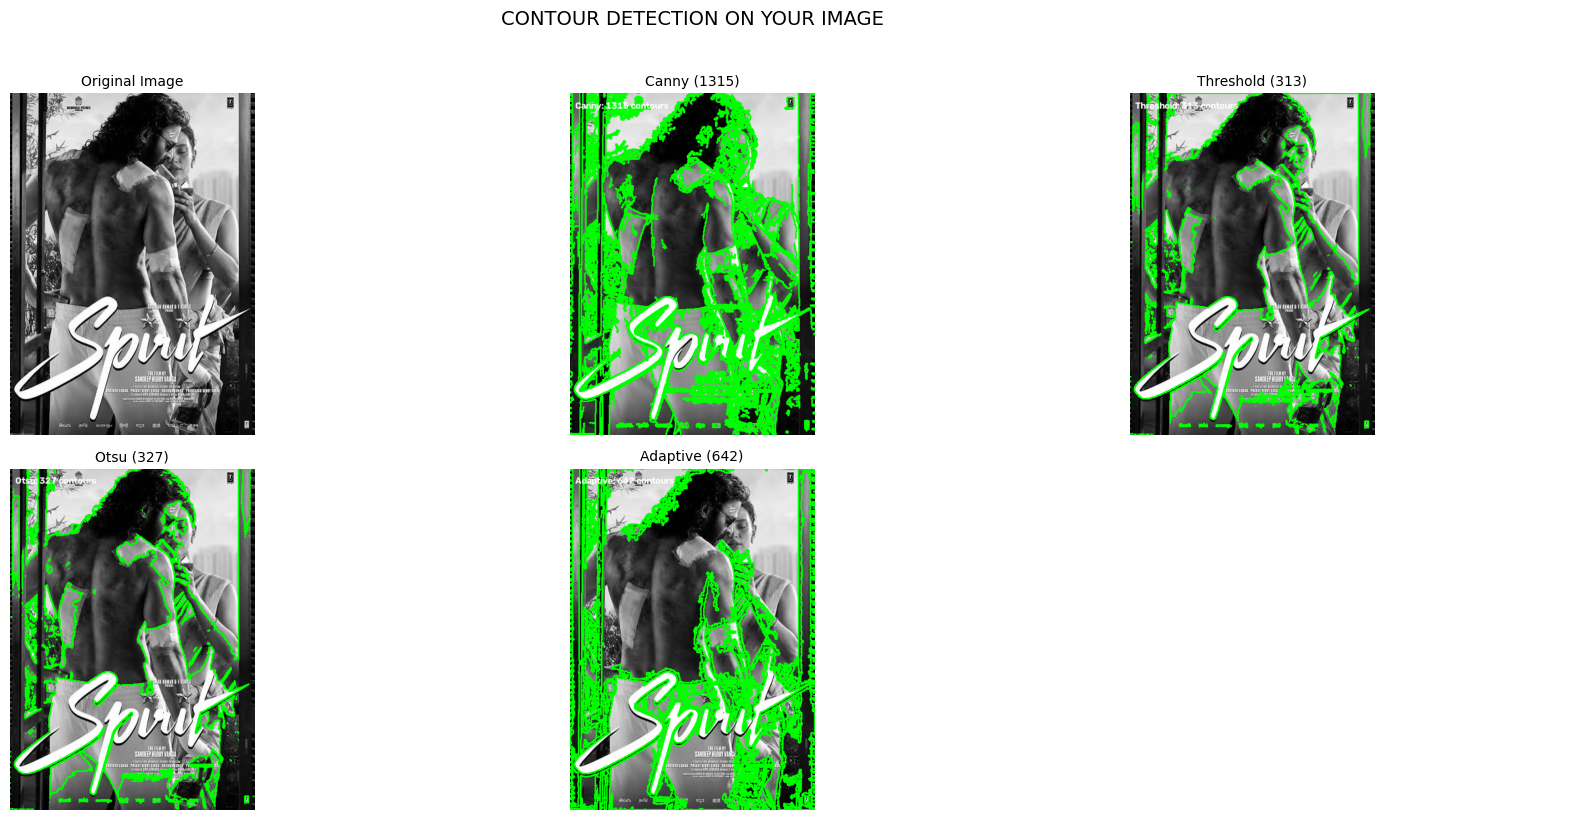


STEP 2: CONTOUR PROPERTIES ANALYSIS

PRACTICAL: CONTOUR PROPERTIES OF YOUR IMAGE

Analyzing 14 significant contours from your image...


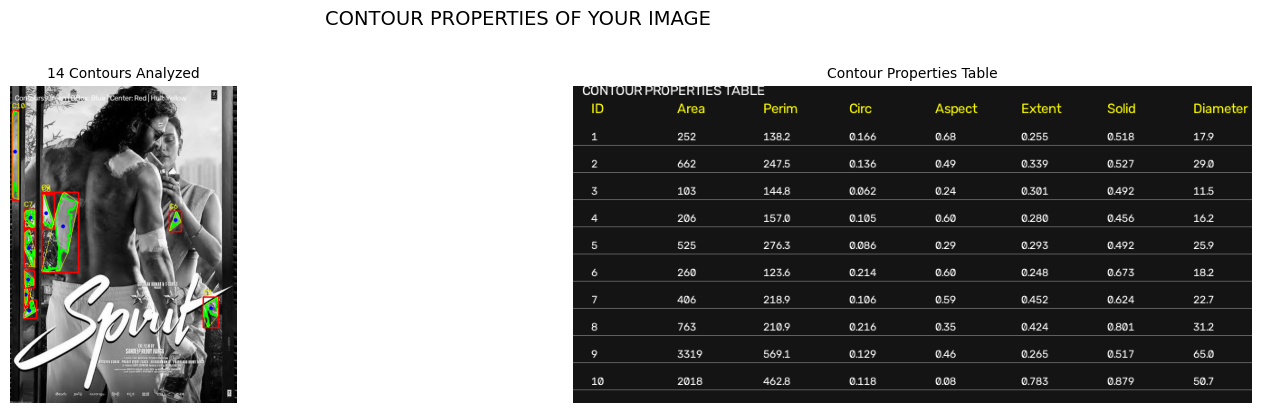


----------------------------------------------------------------------
CONTOUR PROPERTIES SUMMARY
----------------------------------------------------------------------

Contour 1:
  • Area: 252.00 pixels
  • Perimeter: 138.23 pixels
  • Centroid: (39, 463)
  • Bounding Box: (28, 441, 26, 38)
  • Circularity: 0.166 
  • Aspect Ratio: 0.684
  • Extent: 0.255
  • Solidity: 0.518

Contour 2:
  • Area: 662.00 pixels
  • Perimeter: 247.48 pixels
  • Centroid: (414, 458)
  • Bounding Box: (398, 435, 31, 63)
  • Circularity: 0.136 
  • Aspect Ratio: 0.492
  • Extent: 0.339
  • Solidity: 0.527

Contour 3:
  • Area: 103.00 pixels
  • Perimeter: 144.77 pixels
  • Centroid: (32, 430)
  • Bounding Box: (29, 416, 9, 38)
  • Circularity: 0.062 
  • Aspect Ratio: 0.237
  • Extent: 0.301
  • Solidity: 0.492

Contour 4:
  • Area: 205.50 pixels
  • Perimeter: 156.95 pixels
  • Centroid: (37, 399)
  • Bounding Box: (29, 381, 21, 35)
  • Circularity: 0.105 
  • Aspect Ratio: 0.600
  • Extent: 0.280
  • S

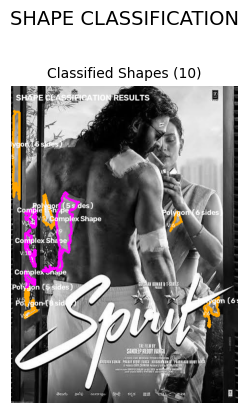


----------------------------------------------------------------------
SHAPES FOUND IN YOUR IMAGE:
----------------------------------------------------------------------
  1. Polygon (8 sides)
  2. Polygon (6 sides)
  3. Polygon (5 sides)
  4. Complex Shape
  5. Complex Shape
  6. Polygon (6 sides)
  7. Complex Shape
  8. Polygon (5 sides)
  9. Complex Shape
  10. Polygon (5 sides)

STEP 4: SHAPE SIMILARITY COMPARISON

PRACTICAL: SHAPE SIMILARITY COMPARISON

Comparing 14 shapes from your image...


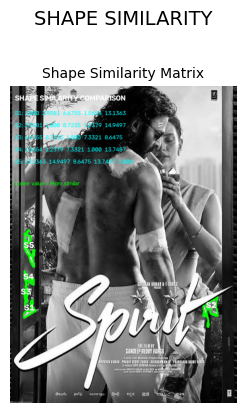


----------------------------------------------------------------------
SHAPE SIMILARITY MATRIX (Lower = More Similar):
----------------------------------------------------------------------
     S1   S2   S3   S4   S5   
S1  1.000 2.9581 6.6755 1.5654 13.1363 
S2  2.9581 1.000 8.7235 1.2379 14.9497 
S3  6.6755 8.7235 1.000 7.3321 8.6475 
S4  1.5654 1.2379 7.3321 1.000 13.7487 
S5  13.1363 14.9497 8.6475 13.7487 1.000 

STEP 5: SKELETON EXTRACTION

PRACTICAL: SKELETON EXTRACTION


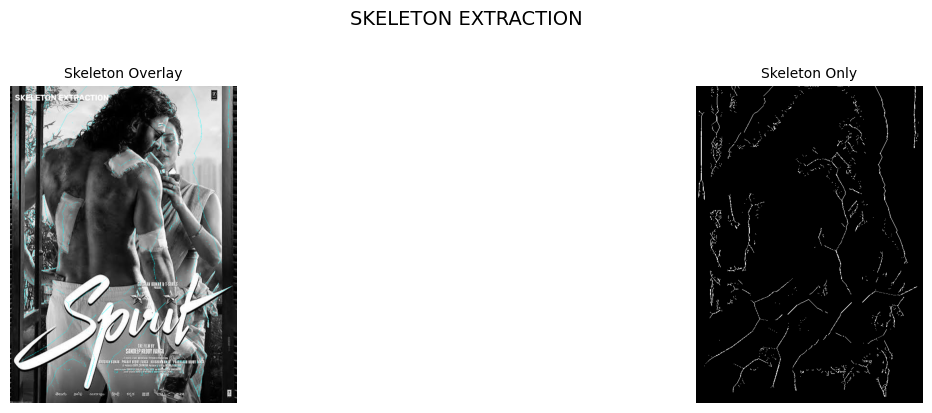


✓ Skeleton extracted from shapes in your image!
  (Yellow lines represent the medial axis)

FINAL SUMMARY - WHAT WAS COMPUTED ON YOUR IMAGE

📊 Your Image: 468x654 pixels

1. Contours Detected: 327
2. Significant Contours: 10
3. Shapes Classified: 10

4. Shapes Found:
   • Polygon (8 sides)
   • Polygon (6 sides)
   • Polygon (5 sides)
   • Complex Shape
   • Complex Shape
   • Polygon (6 sides)
   • Complex Shape
   • Polygon (5 sides)
   • Complex Shape
   • Polygon (5 sides)

5. Properties Computed:
   • Area (pixels²)
   • Perimeter (pixels)
   • Centroid (x, y)
   • Bounding Box (x, y, w, h)
   • Circularity (1 = perfect circle)
   • Aspect Ratio (width/height)
   • Extent (area/bbox area)
   • Solidity (area/hull area)
   • Equivalent Diameter

6. Shape Comparison: Similarity matrix computed
7. Skeleton: Medial axis extracted


✅ All computations completed successfully!


In [3]:
# ==================== FULLY PRACTICAL SHAPE & OBJECT REPRESENTATION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow scipy scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time
import math

# ==================== PRACTICAL CONTOUR DETECTION ====================

def detect_contours_practical(img):
    """
    ACTUALLY detects contours from YOUR image using 4 different methods
    Returns: Detected contours from each method
    """
    print("\n" + "="*70)
    print("PRACTICAL: CONTOUR DETECTION ON YOUR IMAGE")
    print("="*70)

    results = []
    titles = []
    contours_list = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # Method 1: Canny Edge + Contours
    print("\n[1] Detecting contours using Canny Edge...")
    start = time()
    edges = cv2.Canny(img, 50, 150)
    contours1, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img1 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img1, contours1, -1, (0, 255, 0), 2)
    cv2.putText(contour_img1, f"Canny: {len(contours1)} contours", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    results.append(contour_img1)
    titles.append(f"Canny ({len(contours1)})")
    print(f"  ✓ Found {len(contours1)} contours in {time()-start:.3f}s")
    contours_list.append(contours1)

    # Method 2: Global Threshold
    print("\n[2] Detecting contours using Global Threshold...")
    start = time()
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    contours2, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img2 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img2, contours2, -1, (0, 255, 0), 2)
    cv2.putText(contour_img2, f"Threshold: {len(contours2)} contours", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    results.append(contour_img2)
    titles.append(f"Threshold ({len(contours2)})")
    print(f"  ✓ Found {len(contours2)} contours in {time()-start:.3f}s")
    contours_list.append(contours2)

    # Method 3: Otsu Threshold
    print("\n[3] Detecting contours using Otsu Threshold...")
    start = time()
    _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours3, _ = cv2.findContours(otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img3 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img3, contours3, -1, (0, 255, 0), 2)
    cv2.putText(contour_img3, f"Otsu: {len(contours3)} contours", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    results.append(contour_img3)
    titles.append(f"Otsu ({len(contours3)})")
    print(f"  ✓ Found {len(contours3)} contours in {time()-start:.3f}s")
    contours_list.append(contours3)

    # Method 4: Adaptive Threshold
    print("\n[4] Detecting contours using Adaptive Threshold...")
    start = time()
    adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
    contours4, _ = cv2.findContours(adaptive, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img4 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img4, contours4, -1, (0, 255, 0), 2)
    cv2.putText(contour_img4, f"Adaptive: {len(contours4)} contours", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    results.append(contour_img4)
    titles.append(f"Adaptive ({len(contours4)})")
    print(f"  ✓ Found {len(contours4)} contours in {time()-start:.3f}s")
    contours_list.append(contours4)

    # Display results
    display_results_grid(results, titles, "CONTOUR DETECTION ON YOUR IMAGE")

    return contours_list, results, titles

# ==================== PRACTICAL CONTOUR PROPERTIES ====================

def analyze_contour_properties_practical(img, contours):
    """
    ACTUALLY computes properties of contours from YOUR image
    """
    print("\n" + "="*70)
    print("PRACTICAL: CONTOUR PROPERTIES OF YOUR IMAGE")
    print("="*70)

    # Filter small contours
    filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

    if not filtered:
        print("\n⚠ No significant contours found in your image!")
        print("  Try using an image with clear shapes/objects.")
        return [], []

    print(f"\nAnalyzing {len(filtered)} significant contours from your image...")

    results = []
    titles = []
    properties = []

    # Create visualization
    vis_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Process each contour
    for i, cnt in enumerate(filtered[:10]):  # Process up to 10 contours
        # Compute properties
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)

        # Centroid
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0

        # Bounding rectangle
        x, y, w, h = cv2.boundingRect(cnt)

        # Convex hull
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)

        # Circularity
        circularity = (4 * np.pi * area) / (perimeter * perimeter) if perimeter > 0 else 0

        # Aspect ratio
        aspect_ratio = w / h if h > 0 else 0

        # Extent
        extent = area / (w * h) if w * h > 0 else 0

        # Solidity
        solidity = area / hull_area if hull_area > 0 else 0

        # Equivalent diameter
        equiv_diameter = np.sqrt(4 * area / np.pi)

        # Store properties
        properties.append({
            'id': i+1,
            'area': area,
            'perimeter': perimeter,
            'centroid': (cx, cy),
            'bbox': (x, y, w, h),
            'circularity': circularity,
            'aspect_ratio': aspect_ratio,
            'extent': extent,
            'solidity': solidity,
            'equiv_diameter': equiv_diameter
        })

        # Draw on image
        cv2.drawContours(vis_img, [cnt], -1, (0, 255, 0), 2)
        cv2.rectangle(vis_img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.circle(vis_img, (cx, cy), 4, (0, 0, 255), -1)
        cv2.drawContours(vis_img, [hull], -1, (255, 255, 0), 1)
        cv2.putText(vis_img, f"C{i+1}", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 1)

    cv2.putText(vis_img, f"Contours: Green | BBox: Blue | Center: Red | Hull: Yellow",
               (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    results.append(vis_img)
    titles.append(f"{len(filtered)} Contours Analyzed")

    # Create property table
    table_img = create_property_table_practical(properties)
    results.append(table_img)
    titles.append("Contour Properties Table")

    # Display
    display_results_grid(results, titles, "CONTOUR PROPERTIES OF YOUR IMAGE")

    # Print summary
    print("\n" + "-"*70)
    print("CONTOUR PROPERTIES SUMMARY")
    print("-"*70)
    for prop in properties:
        print(f"\nContour {prop['id']}:")
        print(f"  • Area: {prop['area']:.2f} pixels")
        print(f"  • Perimeter: {prop['perimeter']:.2f} pixels")
        print(f"  • Centroid: ({prop['centroid'][0]}, {prop['centroid'][1]})")
        print(f"  • Bounding Box: {prop['bbox']}")
        print(f"  • Circularity: {prop['circularity']:.3f} {'★ Perfect Circle!' if prop['circularity'] > 0.9 else ''}")
        print(f"  • Aspect Ratio: {prop['aspect_ratio']:.3f}")
        print(f"  • Extent: {prop['extent']:.3f}")
        print(f"  • Solidity: {prop['solidity']:.3f}")

    return properties, results, titles

def create_property_table_practical(properties):
    """Create table of contour properties"""
    if not properties:
        return np.zeros((100, 400), dtype=np.uint8)

    table_img = np.zeros((50 + len(properties) * 30, 750, 3), dtype=np.uint8)
    table_img[:, :, :] = 20

    headers = ["ID", "Area", "Perim", "Circ", "Aspect", "Extent", "Solid", "Diameter"]
    for i, header in enumerate(headers):
        cv2.putText(table_img, header, (20 + i*95, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 1)

    for row, prop in enumerate(properties):
        y = 60 + row * 30
        data = [
            str(prop['id']),
            f"{prop['area']:.0f}",
            f"{prop['perimeter']:.1f}",
            f"{prop['circularity']:.3f}",
            f"{prop['aspect_ratio']:.2f}",
            f"{prop['extent']:.3f}",
            f"{prop['solidity']:.3f}",
            f"{prop['equiv_diameter']:.1f}"
        ]
        for i, val in enumerate(data):
            cv2.putText(table_img, val, (20 + i*95, y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.line(table_img, (0, y+5), (750, y+5), (100,100,100), 1)

    cv2.putText(table_img, "CONTOUR PROPERTIES TABLE", (10, 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    return table_img

# ==================== PRACTICAL SHAPE CLASSIFICATION ====================

def classify_shapes_practical(img, contours):
    """
    ACTUALLY classifies shapes from YOUR image
    """
    print("\n" + "="*70)
    print("PRACTICAL: SHAPE CLASSIFICATION FROM YOUR IMAGE")
    print("="*70)

    filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

    if not filtered:
        print("\n⚠ No shapes found in your image!")
        return [], [], []

    results = []
    titles = []

    # Create classification visualization
    class_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    shapes_found = []

    for i, cnt in enumerate(filtered[:10]):
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)

        # Shape classification
        if perimeter > 0:
            circularity = (4 * np.pi * area) / (perimeter * perimeter)
        else:
            circularity = 0

        # Approximate polygon
        epsilon = 0.02 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        vertices = len(approx)

        # Classify
        if circularity > 0.85:
            shape_name = "Circle"
            color = (0, 255, 255)  # Yellow
        elif vertices == 3:
            shape_name = "Triangle"
            color = (255, 0, 0)  # Blue
        elif vertices == 4:
            # Check if square or rectangle
            x, y, w, h = cv2.boundingRect(cnt)
            aspect = w / h if h > 0 else 0
            if 0.85 < aspect < 1.15:
                shape_name = "Square"
                color = (0, 255, 0)  # Green
            else:
                shape_name = "Rectangle"
                color = (0, 255, 0)  # Green
        elif 5 <= vertices <= 8:
            shape_name = f"Polygon ({vertices} sides)"
            color = (255, 165, 0)  # Orange
        else:
            shape_name = "Complex Shape"
            color = (255, 0, 255)  # Magenta

        shapes_found.append(shape_name)

        # Draw with classification
        cv2.drawContours(class_img, [cnt], -1, color, 3)

        # Add label
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(class_img, shape_name, (cx-30, cy-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

        # Add vertices count
        cv2.putText(class_img, f"V:{vertices}", (cx-20, cy+15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    cv2.putText(class_img, "SHAPE CLASSIFICATION RESULTS", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    results.append(class_img)
    titles.append(f"Classified Shapes ({len(shapes_found)})")

    # Display
    display_results_grid(results, titles, "SHAPE CLASSIFICATION")

    # Print results
    print("\n" + "-"*70)
    print("SHAPES FOUND IN YOUR IMAGE:")
    print("-"*70)
    for i, shape in enumerate(shapes_found):
        print(f"  {i+1}. {shape}")

    return shapes_found, results, titles

# ==================== PRACTICAL SHAPE SIMILARITY ====================

def compare_shapes_practical(img, contours):
    """
    ACTUALLY compares shapes from YOUR image
    """
    print("\n" + "="*70)
    print("PRACTICAL: SHAPE SIMILARITY COMPARISON")
    print("="*70)

    filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

    if len(filtered) < 2:
        print("\n⚠ Need at least 2 shapes for comparison!")
        return [], []

    print(f"\nComparing {len(filtered)} shapes from your image...")

    # Create comparison visualization
    compare_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Draw contours with IDs
    for i, cnt in enumerate(filtered[:5]):
        cv2.drawContours(compare_img, [cnt], -1, (0, 255, 0), 2)
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(compare_img, f"S{i+1}", (cx-10, cy),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    cv2.putText(compare_img, "SHAPE SIMILARITY COMPARISON", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

    # Compute similarity matrix
    n_shapes = min(5, len(filtered))
    similarity_matrix = np.zeros((n_shapes, n_shapes))

    for i in range(n_shapes):
        for j in range(n_shapes):
            if i != j:
                similarity = cv2.matchShapes(filtered[i], filtered[j], cv2.CONTOURS_MATCH_I1, 0)
                similarity_matrix[i, j] = similarity

    # Display similarity matrix as text
    y_pos = 60
    for i in range(n_shapes):
        row_text = f"S{i+1}: "
        for j in range(n_shapes):
            if i == j:
                row_text += "1.000  "
            else:
                row_text += f"{similarity_matrix[i, j]:.4f}  "
        cv2.putText(compare_img, row_text, (10, y_pos),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,255), 1)
        y_pos += 25

    cv2.putText(compare_img, "Lower value = More similar", (10, y_pos+20),
               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

    results = [compare_img]
    titles = ["Shape Similarity Matrix"]

    display_results_grid(results, titles, "SHAPE SIMILARITY")

    print("\n" + "-"*70)
    print("SHAPE SIMILARITY MATRIX (Lower = More Similar):")
    print("-"*70)
    print("     ", end="")
    for i in range(n_shapes):
        print(f"S{i+1}   ", end="")
    print()

    for i in range(n_shapes):
        print(f"S{i+1}  ", end="")
        for j in range(n_shapes):
            if i == j:
                print("1.000 ", end="")
            else:
                print(f"{similarity_matrix[i, j]:.4f} ", end="")
        print()

    return results, titles

# ==================== PRACTICAL SKELETON EXTRACTION ====================

def extract_skeleton_practical(img, contours):
    """
    ACTUALLY extracts skeleton from shapes in YOUR image
    """
    print("\n" + "="*70)
    print("PRACTICAL: SKELETON EXTRACTION")
    print("="*70)

    # Create binary image from contours
    mask = np.zeros_like(img)
    for cnt in contours:
        if cv2.contourArea(cnt) > 100:
            cv2.drawContours(mask, [cnt], -1, 255, -1)

    # Skeletonization using thinning
    skeleton = np.zeros_like(img)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    # Iterative thinning
    temp = mask.copy()
    while True:
        eroded = cv2.erode(temp, kernel)
        temp2 = cv2.dilate(eroded, kernel)
        temp3 = cv2.subtract(temp, temp2)
        skeleton = cv2.bitwise_or(skeleton, temp3)
        temp = eroded.copy()

        if cv2.countNonZero(temp) == 0:
            break

    # Visualization
    skel_vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    skel_vis[skeleton > 0] = [0, 255, 255]  # Yellow skeleton

    # Overlay on original
    overlay = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), 0.5, skel_vis, 0.5, 0)
    cv2.putText(overlay, "SKELETON EXTRACTION", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

    results = [overlay, skeleton]
    titles = ["Skeleton Overlay", "Skeleton Only"]

    display_results_grid(results, titles, "SKELETON EXTRACTION")

    print("\n✓ Skeleton extracted from shapes in your image!")
    print("  (Yellow lines represent the medial axis)")

    return results, titles

# ==================== DISPLAY FUNCTION ====================

def display_results_grid(results, titles, title_prefix=""):
    """Display results in a grid"""
    if not results:
        return

    cols = min(3, len(results))
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))

    # Fix for single row case
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            if len(img_result.shape) == 3:
                axes[row, col].imshow(img_result)
            else:
                axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ==================== MAIN ====================

def create_test_image(rows=256, cols=256):
    """Create a synthetic test image with shapes"""
    img = np.zeros((rows, cols), dtype=np.uint8)

    # Circle
    cv2.circle(img, (80, 80), 40, 255, -1)

    # Square
    cv2.rectangle(img, (140, 40), (200, 100), 255, -1)

    # Triangle
    pts = np.array([[250, 100], [220, 40], [280, 40]], np.int32)
    cv2.fillPoly(img, [pts], 255)

    # Rectangle
    cv2.rectangle(img, (40, 140), (120, 220), 255, -1)

    # Star-like shape
    center = (180, 170)
    pts = []
    for i in range(10):
        angle = i * 36 * np.pi / 180
        r = 40 if i % 2 == 0 else 20
        x = center[0] + int(r * np.cos(angle))
        y = center[1] + int(r * np.sin(angle))
        pts.append([x, y])
    cv2.fillPoly(img, [np.array(pts)], 255)

    # Noise
    noise = np.random.randint(0, 30, (rows, cols))
    img = np.clip(img + noise, 0, 255).astype(np.uint8)

    return img

def main():
    print("\n" + "="*70)
    print("FULLY PRACTICAL SHAPE & OBJECT REPRESENTATION")
    print("ALL computations performed on YOUR image")
    print("="*70)
    print("\n✅ Detects contours from YOUR image")
    print("✅ Computes properties of YOUR contours")
    print("✅ Classifies shapes in YOUR image")
    print("✅ Compares shapes in YOUR image")
    print("✅ Extracts skeleton from YOUR image")
    print("\n" + "="*70)

    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test image with shapes")
    print("-"*50)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test image with shapes...")
        img = create_test_image(400, 400)
        status = "Using test image with shapes"
    else:
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    # Resize to 720p max
    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h} (max 720p)")
        img = cv2.resize(img, (new_w, new_h))

    # ===== STEP 1: CONTOUR DETECTION =====
    print("\n" + "="*70)
    print("STEP 1: CONTOUR DETECTION ON YOUR IMAGE")
    print("="*70)
    contours_list, _, _ = detect_contours_practical(img)

    # Use contours from best method (Otsu)
    best_contours = contours_list[2] if len(contours_list) > 2 else contours_list[0]

    if len(best_contours) == 0:
        print("\n⚠ No contours found! Try using a different image.")
        return

    # ===== STEP 2: CONTOUR PROPERTIES =====
    print("\n" + "="*70)
    print("STEP 2: CONTOUR PROPERTIES ANALYSIS")
    print("="*70)
    properties, _, _ = analyze_contour_properties_practical(img, best_contours)

    # ===== STEP 3: SHAPE CLASSIFICATION =====
    print("\n" + "="*70)
    print("STEP 3: SHAPE CLASSIFICATION")
    print("="*70)
    shapes, _, _ = classify_shapes_practical(img, best_contours)

    # ===== STEP 4: SHAPE SIMILARITY =====
    print("\n" + "="*70)
    print("STEP 4: SHAPE SIMILARITY COMPARISON")
    print("="*70)
    _, _ = compare_shapes_practical(img, best_contours)

    # ===== STEP 5: SKELETON EXTRACTION =====
    print("\n" + "="*70)
    print("STEP 5: SKELETON EXTRACTION")
    print("="*70)
    _, _ = extract_skeleton_practical(img, best_contours)

    # ===== FINAL SUMMARY =====
    print("\n" + "="*70)
    print("FINAL SUMMARY - WHAT WAS COMPUTED ON YOUR IMAGE")
    print("="*70)
    print(f"\n📊 Your Image: {img.shape[1]}x{img.shape[0]} pixels")
    print(f"\n1. Contours Detected: {len(best_contours)}")
    print(f"2. Significant Contours: {len(properties)}")
    print(f"3. Shapes Classified: {len(shapes) if shapes else 0}")

    if shapes:
        print("\n4. Shapes Found:")
        for i, shape in enumerate(shapes):
            print(f"   • {shape}")

    print("\n5. Properties Computed:")
    print("   • Area (pixels²)")
    print("   • Perimeter (pixels)")
    print("   • Centroid (x, y)")
    print("   • Bounding Box (x, y, w, h)")
    print("   • Circularity (1 = perfect circle)")
    print("   • Aspect Ratio (width/height)")
    print("   • Extent (area/bbox area)")
    print("   • Solidity (area/hull area)")
    print("   • Equivalent Diameter")

    print("\n6. Shape Comparison: Similarity matrix computed")
    print("7. Skeleton: Medial axis extracted")

    print("\n" + "="*70)
    print("\n✅ All computations completed successfully!")

if __name__ == "__main__":
    main()